<a href="https://www.kaggle.com/code/nicapotato/linkedin-job-postings-2023-eda?scriptVersionId=320614297" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install watermark
!pip install nicaviz

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import nicaviz
import string
import seaborn as sns
import time
import matplotlib.pyplot as plt
import itertools
import glob
import re
from nltk.corpus import stopwords
import math

sns.set_style("whitegrid")

%load_ext watermark
%watermark 

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

notebookstart = time.time()
%watermark --iversions

Last updated: 2026-05-19T15:19:06.081216+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 8.14.0

Compiler    : GCC 12.3.0
OS          : Linux
Release     : 6.6.122+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.7.2
nicaviz   : 0.1.4
numpy     : 1.23.5
pandas    : 2.0.3
re        : 2.2.1
seaborn   : 0.12.2



In [4]:
df = pd.read_csv('/kaggle/input/linkedin-job-postings/postings.csv', index_col='job_id')
df.sample(5)

,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
job_id,,,,,,,,,,,,,,,,,,,,,
3885867756,USAA,P&C Product Management Manager,Why USAA?\n\nLet’s do something that really ma...,NaN,NaN,"Tampa, FL",4501.0,9.0,NaN,NaN,...,NaN,1.712380e+12,dsp.prng.co,0,FULL_TIME,NaN,NaN,NaN,33602.0,12057.0
3901346946,Compunnel Inc.,Site Reliability Engineer,Position: Site Reliability EngineerLocation: S...,NaN,NaN,"San Leandro, CA",16690.0,24.0,NaN,NaN,...,NaN,1.713450e+12,NaN,0,CONTRACT,NaN,NaN,NaN,94577.0,6001.0
3895802285,"Westminster Canterbury Lynchburg, Inc.",Cook I,"Westminster Canterbury of Lynchburg, a 5-Star ...",NaN,NaN,Greater Lynchburg Area,6844514.0,2.0,NaN,NaN,...,Must be a high school graduate or GED.Previous...,1.712896e+12,www.click2apply.net,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN
3904929229,Leftbrain,Senior Accountant,"IMPORTANT: Unfortunately, LinkedIn doesn't off...",110000.0,YEARLY,Los Angeles Metropolitan Area,39729811.0,122.0,NaN,85000.0,...,NaN,1.713450e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,97500.0,NaN,NaN
3906253163,Salad and Go,Maintenance Technician (Food Manufacturing),Description\n\nSalad and Go is seeking a Maint...,36.0,HOURLY,"Phoenix, AZ",15157241.0,4.0,NaN,30.0,...,NaN,1.713567e+12,apply.workable.com,0,FULL_TIME,USD,BASE_SALARY,68640.0,85003.0,4013.0


In [5]:
df["pay_period"].value_counts()

pay_period
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

In [6]:
time_cols = [
    'original_listed_time',
    'expiry',
    'closed_time',
    'listed_time'
]

In [7]:
#https://www.kaggle.com/code/arshkon/getting-started-basic-analysis
time_multiplier = {'HOURLY': 40*52, 'WEEKLY': 52, 'BIWEEKLY': 52*2, 'MONTHLY': 12, 'YEARLY': 1}

df['normalized_salary'] = df.apply(lambda x: (x['max_salary']+x['min_salary'])/2 if not pd.isnull(x['max_salary']) else x['med_salary'], axis=1)
df['normalized_salary'] = df.apply(
    lambda x: time_multiplier[x['pay_period']] * x['normalized_salary']
    if not pd.isna(x['pay_period']) and not pd.isna(x['normalized_salary'])
    else np.nan,
    axis=1
)

for tc in time_cols:
    df[tc] = pd.to_datetime(df[tc]*1000000)
    
df['sponsored'] = df['sponsored'] == 1
df['sponsored'] = df['sponsored'].astype(str)

In [8]:
display(df.nica.categorical_describe())

Dataframe Dimension: 123849 Rows, 30 Columns


,Unique,Missing,dtype,ValCount 1,Occ,ValCount 2,Occ,ValCount 3,Occ,ValCount 4,Occ,ValCount 5,Occ
Column,,,,,,,,,,,,,
company_name,24428,1719,object,Liberty Healthcare and Rehabilitation Services,1108,The Job Network,1003.0,J. Galt,604.0,TEKsystems,529.0,"Lowe's Companies, Inc.",527.0
title,72521,0,object,Sales Manager,673,Customer Service Representative,373.0,Project Manager,354.0,Administrative Assistant,254.0,Senior Accountant,238.0
description,107827,7,object,Position Summary: Our Sales Manager has managi...,474,Store Family Dollar\n\nGeneral Summary:\n\nWor...,167.0,"JOB GOAL \n Plan, organize and implement an ap...",127.0,Store Dollar Tree\n\nWork where you love to sh...,117.0,Your time. Your Goals. What is DoorDash Availa...,105.0
max_salary,5321,94056,float64,150000.0,648,100000.0,635.0,120000.0,610.0,90000.0,541.0,85000.0,534.0
pay_period,5,87776,object,YEARLY,20628,HOURLY,14741.0,MONTHLY,518.0,WEEKLY,177.0,BIWEEKLY,9.0
location,8526,0,object,United States,8125,"New York, NY",2756.0,"Chicago, IL",1834.0,"Houston, TX",1762.0,"Dallas, TX",1383.0
company_id,24474,1717,float64,53345529.0,1108,167757.0,1003.0,73013724.0,604.0,2152.0,529.0,4128.0,527.0
views,684,1689,float64,4.0,28323,3.0,16960.0,5.0,14513.0,2.0,14417.0,6.0,7834.0
med_salary,1417,117569,float64,20.0,268,18.0,243.0,15.0,177.0,17.0,169.0,16.0,158.0


[Distplots] done in 1.0 s


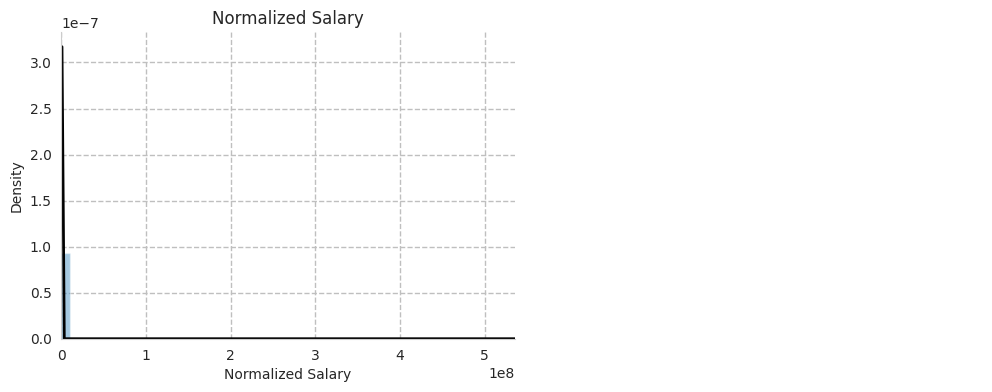

In [9]:
continuous = [
    'normalized_salary'
]

with nicaviz.timer("Distplots"):
    df.nica.mass_plot(
        plt_set = continuous,
        plottype = "distplot")

[Count Plot] done in 2.0 s


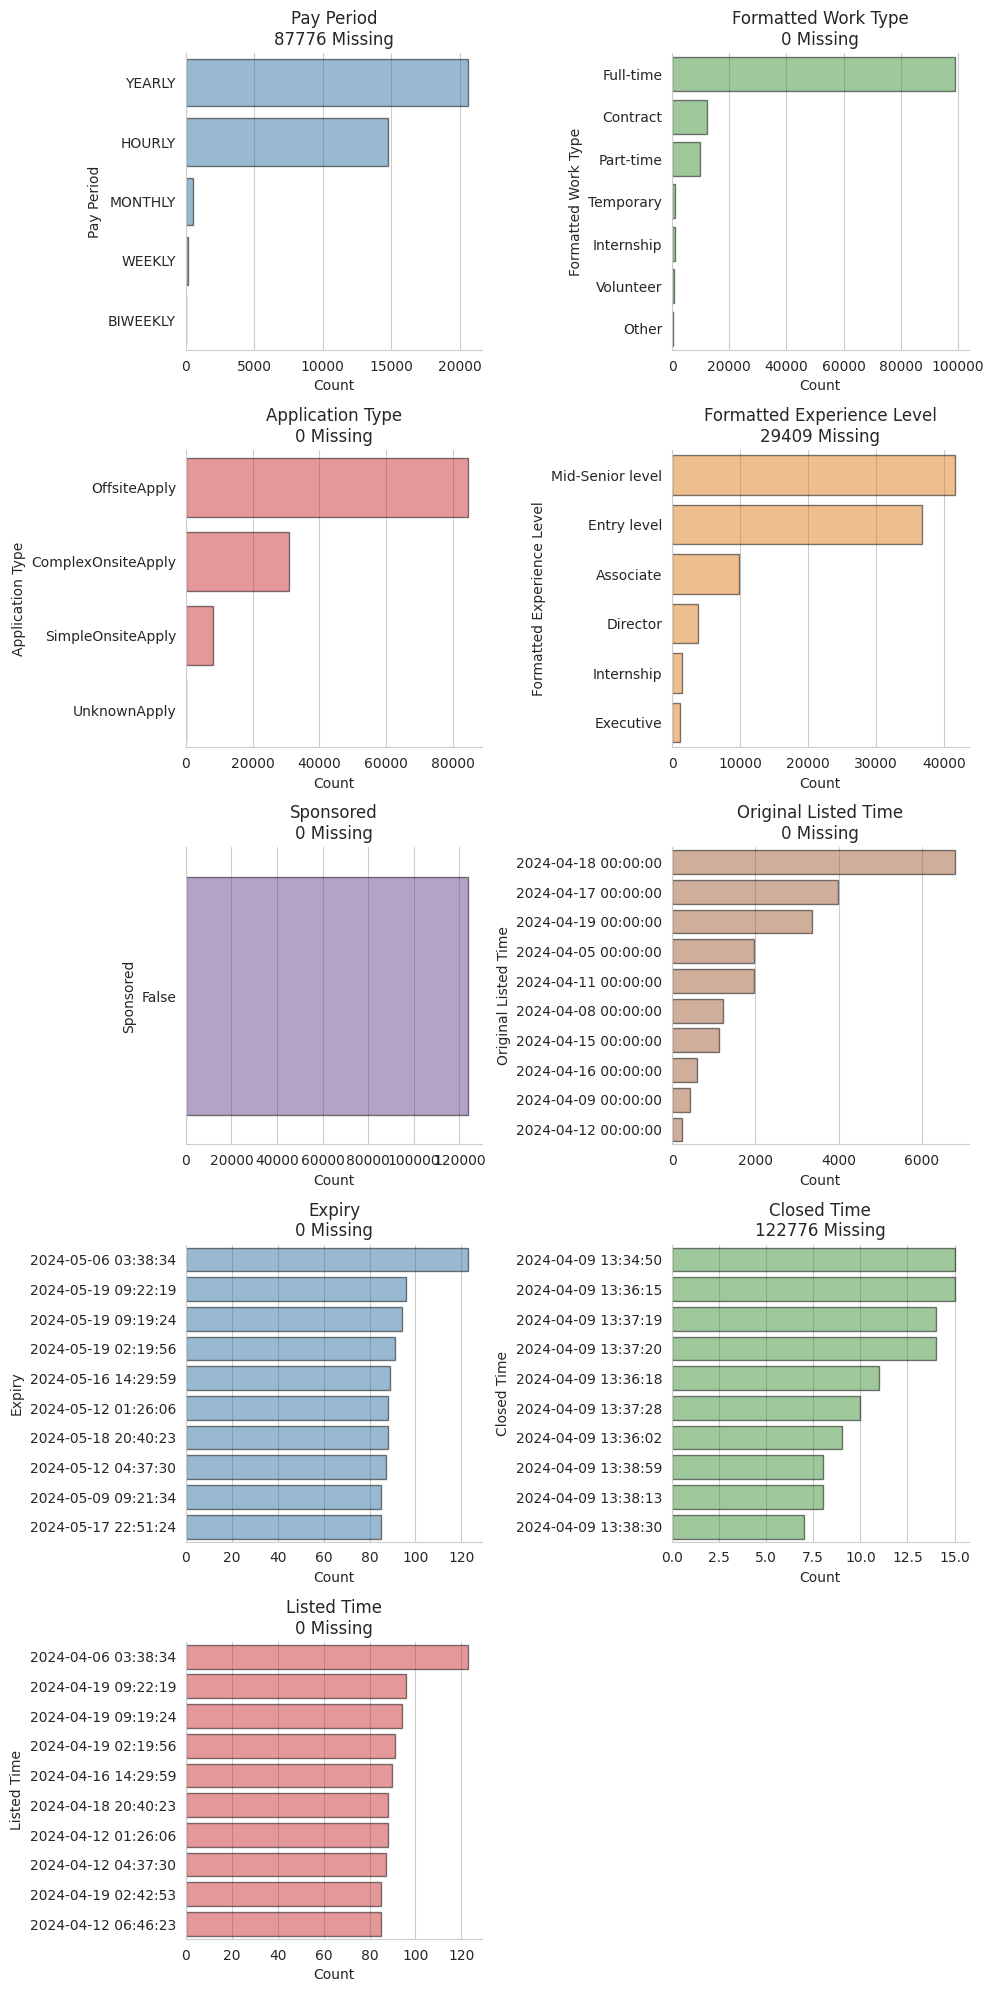

In [10]:
categorical_cols = [
    'pay_period',
    'formatted_work_type',
    'application_type',
    'formatted_experience_level',
    'sponsored'
]

with nicaviz.timer("Count Plot"):
    df.nica.mass_plot(
        plt_set= categorical_cols + time_cols,
        columns = 2,
        plottype = "countplot"
    )

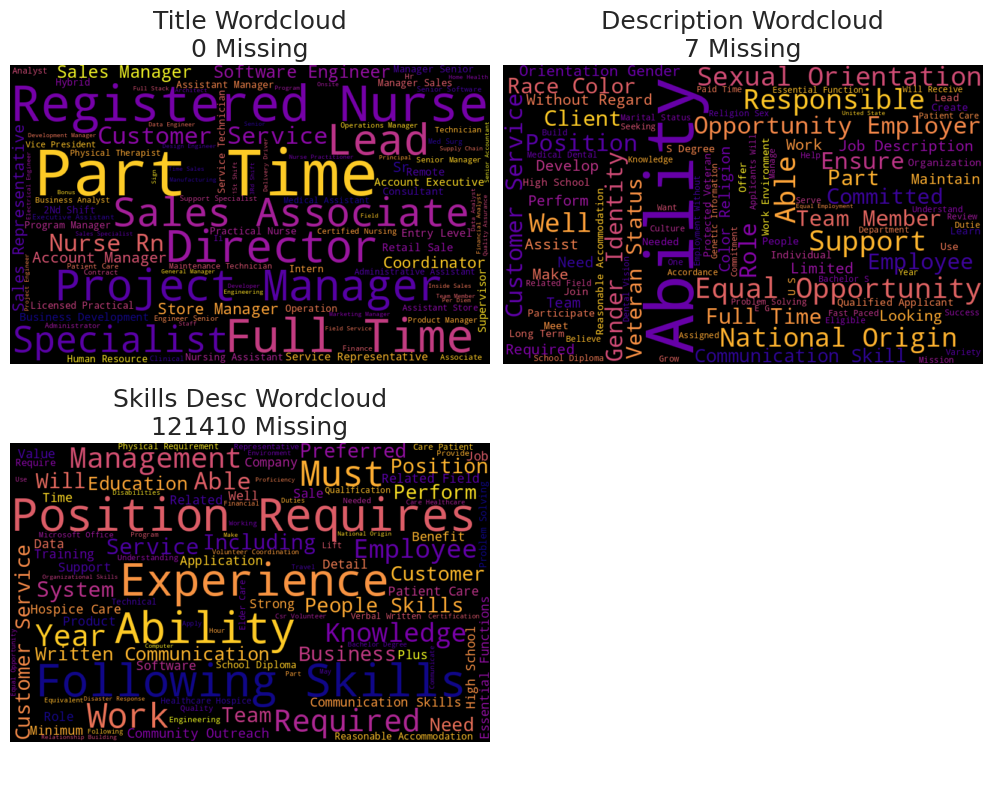

In [11]:
text_cols = [
    'title',
    'description',
    'skills_desc'
]

df.nica.mass_plot(
    plt_set= text_cols,
    plottype = "wordcloud")
plt.show()

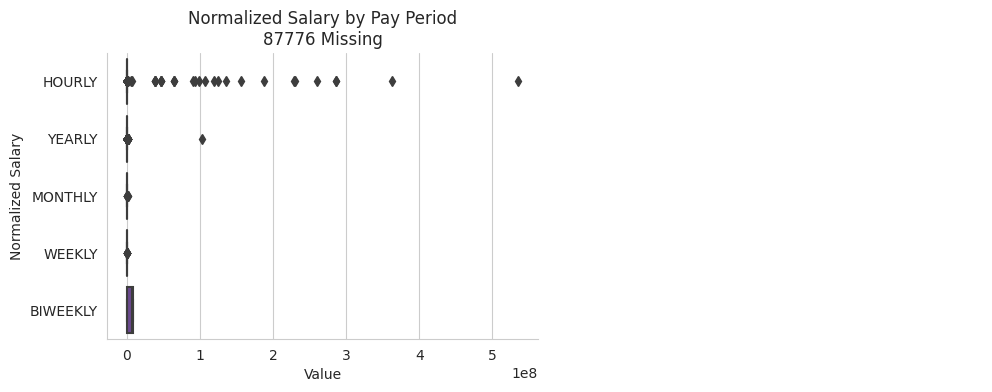

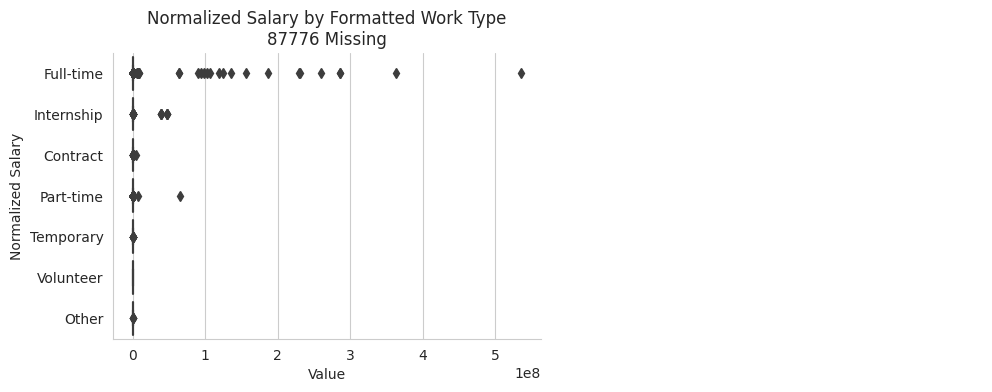

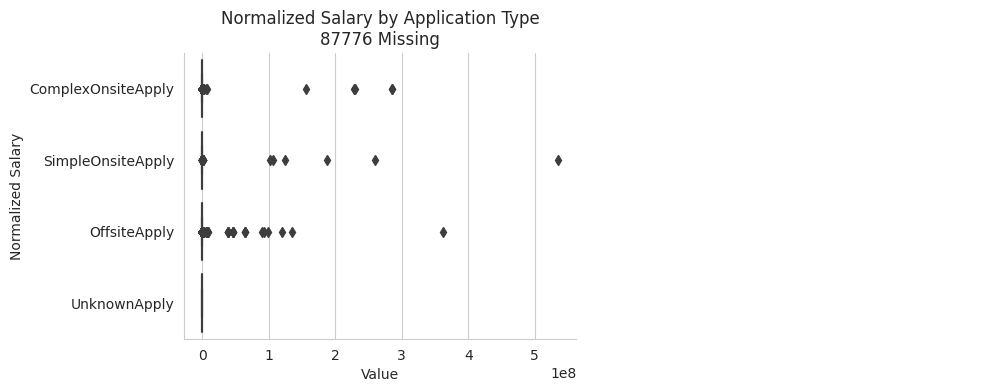

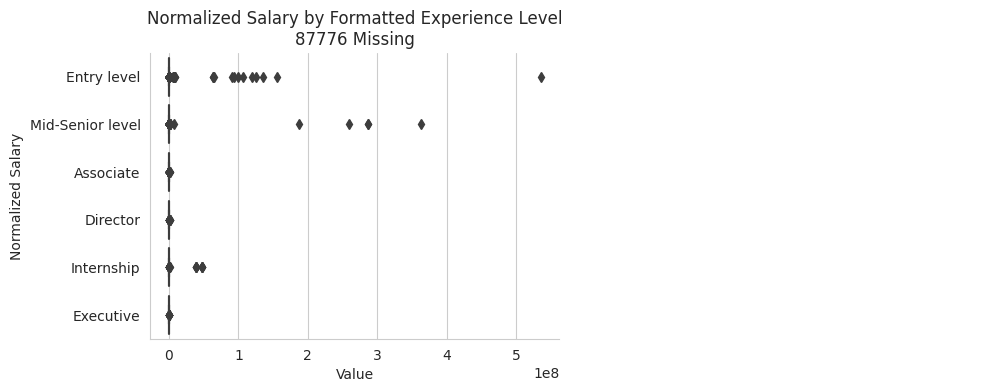

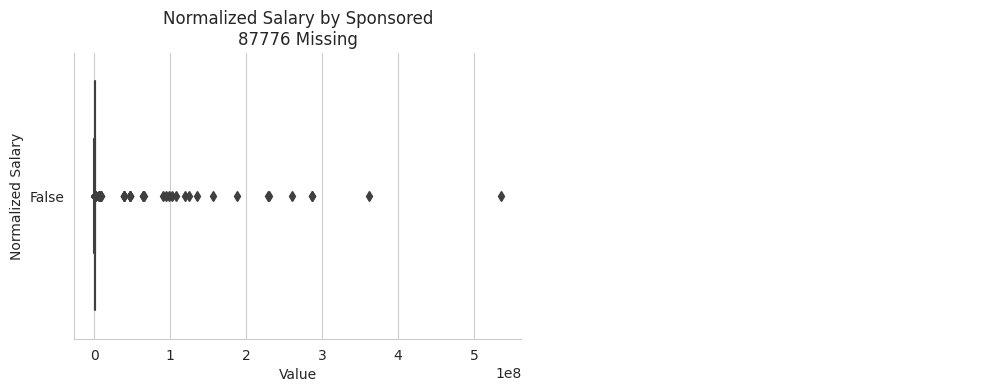

In [12]:
continuous_cols = [
    'normalized_salary'
]

for cat_col in categorical_cols:
    df.nica.mass_plot(
        plt_set = continuous_cols,
        hue = cat_col,
        plottype = "boxplot"
    )

[Pivot Heatmap Plot] done in 7.0 s


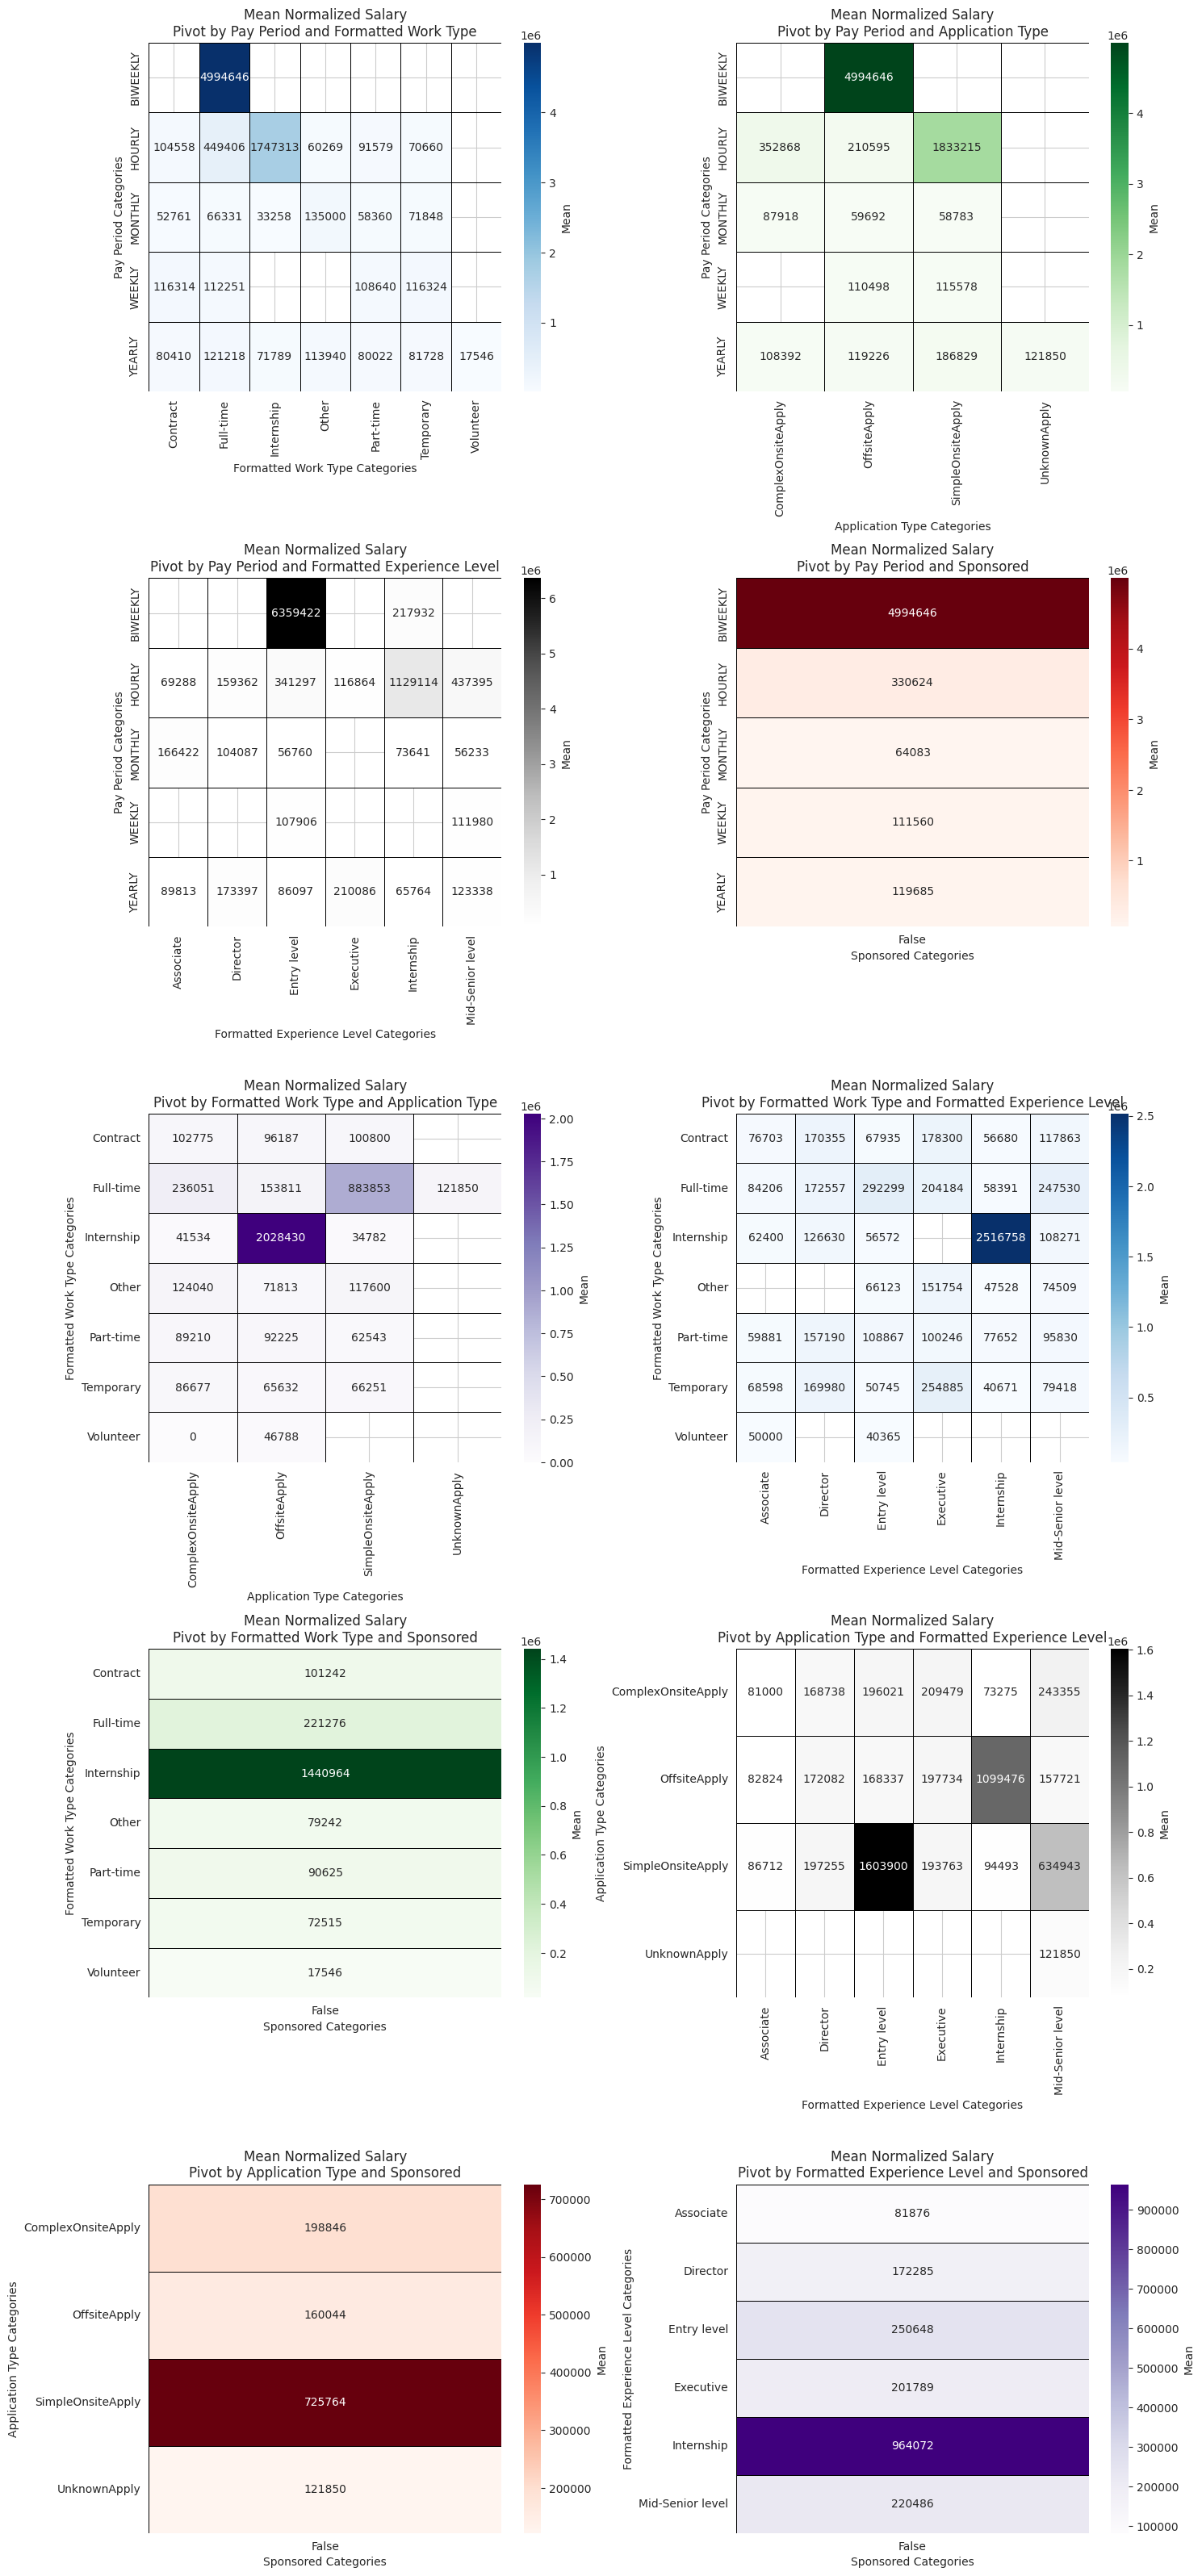

In [13]:
with nicaviz.timer("Pivot Heatmap Plot"):
    df.nica.pivot_plots(categorical_cols, "normalized_salary", np.mean, columns = 2, figsize = [15,32])

In [14]:
print("Notebook Runtime: %0.2f Minutes"%((time.time() - notebookstart)/60))

Notebook Runtime: 4.06 Minutes
